# **11762 Content-Based Image Retrieval**
## Master's Degree in Intelligent Systems
### University of the Balearic Islands
---

##### Write in the following the names of the members of the group:
- **Member 1:** Einar López Altamirano
- **Member 2:** Victor Armando Canales Lima

# **Instructions**

You can find a **pre-configured Conda environment on Aula Digital** with everything required to complete the assignments.

**Do not delete any of the provided cells or functions**. Write your code in the indicated sections. You may add new cells or functions as needed to complete your work.  

Along with this assignment, please submit a comprehensive **report** in PDF format explaining your implemented solutions. The report should include, for example:

- **Technical Explanation**: Clearly describe the algorithms and techniques used, including the relevant code snippets.
- **Results**: Present your results in a clear and concise manner. Use visualizations such as graphs or tables to enhance understanding.
- **Analysis**: Interpret your results and discuss their significance. Consider, for instance, the following questions:
  - Are the results as expected? Why or why not?
  - What factors might have influenced them?
- **Conclusions**: Summarize your findings and provide overall conclusions about your project.
- ---

In [2]:
# Execute this cell to make sure 
# that external modules are reloaded
%load_ext autoreload
%autoreload 2

In [3]:
# Fill the following variable with
# the path to the Holidays dataset
dataset_dir = '/data/image-indexing-11762/holidays_mini'

In [4]:
# Setup code for this assignment
import cv2
import math
import numpy as np
import os
import scipy.cluster.vq as vq
import zipfile
from holidays_dataset_handler import HolidaysDatasetHandler
from pathlib import Path
import assignment2 as a2

# Configuring Matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

import time

# **Introduction**
In this assignment, you will implement and evaluate different methods for image retrieval using the **INRIA Holidays dataset**. Refer to **Assignment 1** for additional details on the dataset structure and the class `HolidaysDatasetHandler`, that will be used again in this assignment for managing the dataset and to evaluate the performance of various indexing methods.

## Loading Keypoints and Descriptors
Unlike in **Assignment 1**, you will now be provided with a set of **precomputed SIFT descriptors** for each image. Therefore, you do not need to extract these features from scratch as we did previously. Instead, you will use the provided **SIFT keypoints and descriptors** along with the dataset.

To utilize these precomputed features, simply load them when initializing a `HolidaysDatasetHandler` object by setting the `load_features` parameter to `True`, as shown below:

In [6]:
# Load dataset with precomputed SIFT features
dataset = HolidaysDatasetHandler(dataset_dir, load_features=True)

Loading features ...
Completed!


This will ensure that all necessary keypoints and descriptors are available for retrieval tasks without requiring additional computation.

> **Some images do not have keypoints / descriptors. Take this into account when you develop your solution.**

# **$k$-d Trees**

In this section, you will use a set of randomized $k$-d trees to index a database of images. 

- To achieve this, start by implementing the function `build_kdtree` in the `assignment2.py` file. This function will take a dataset as input and construct a set of randomized $k$-d trees, using the FLANN library format.

> **Useful links**: [cv2.FlannBasedMatcher](https://docs.opencv.org/4.5.5/dc/de2/classcv_1_1FlannBasedMatcher.html), [Possible algorithms to create an index](https://docs.opencv.org/4.5.5/db/d18/classcv_1_1flann_1_1GenericIndex.html#a8fff14185f9f3d2f2311b528f65b146c), [Algorithm IDs](https://github.com/opencv/opencv/blob/master/modules/flann/include/opencv2/flann/defines.h#L70)

- Next, implement the function `search_kdtree` in the `assignment2.py` file. This function performs a nearest neighbor search using FLANN (previously trained with `build_kdtree`) on the provided query descriptors, and applies Lowe's ratio test to filter weak matches. It returns a list of image indices, ordered by the number of matches found, to identify the most relevant images in the database.

**Task 1:**

Using the `HolidaysDatasetHandler` and the functions you have implemented, your task in the following cell is to compute the **mean Average Precision (mAP)** of the image retrieval system for this dataset, utilizing an FLANN-based kd-tree index. To reduce the computational load of the notebook, limit the number of descriptors per image to **400**. Use **4** trees.

In [9]:
# Fill this variable with the resulting mAP
mAP_kdtree = 0.0

# YOUR CODE HERE
flann, image_map = a2.build_kdtree(dataset, max_descriptors=400, num_trees=4)
ranked_dict = {}
for query_image in dataset.get_query_images():
    query_descs = dataset.get_descriptors(query_image)
    if query_descs is None:
        continue
    query_descs = query_descs[:400]
    ranked_indices = a2.search_kdtree(query_descs, flann)
    ranked_list = [image_map[idx] for idx in ranked_indices]
    ranked_dict[query_image] = ranked_list
mAP_kdtree = dataset.compute_mAP(ranked_dict)
# -----

print('Mean Average Precision (mAP): %.5f' % mAP_kdtree)

Mean Average Precision (mAP): 0.81754


**Task 2:**

Are the results consistent? Do you get the same mAP every time? Explain why this may or may not happen when running the procedure multiple times using the same trees, without rebuilding them.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

_Test without rebuilding $k$-d Trees_

In [10]:
for i in range(5):
    ranked_dict = {}
    for query_image in dataset.get_query_images():
        query_descs = dataset.get_descriptors(query_image)
        if query_descs is None:
            continue
        query_descs = query_descs[:400]
        ranked_indices = a2.search_kdtree(query_descs, flann)
        ranked_list = [image_map[idx] for idx in ranked_indices]
        ranked_dict[query_image] = ranked_list
    mAP_kdtree = dataset.compute_mAP(ranked_dict)
    print(f'Experiment {i+1} - mAP: %.5f' % mAP_kdtree)

Experiment 1 - mAP: 0.81754
Experiment 2 - mAP: 0.81754
Experiment 3 - mAP: 0.81754
Experiment 4 - mAP: 0.81754
Experiment 5 - mAP: 0.81754


_Test rebuilding $k$-d Trees_

In [11]:
for i in range(5):
    flann, image_map = a2.build_kdtree(dataset, max_descriptors=400, num_trees=4)
    ranked_dict = {}
    for query_image in dataset.get_query_images():
        query_descs = dataset.get_descriptors(query_image)
        if query_descs is None:
            continue
        query_descs = query_descs[:400]
        ranked_indices = a2.search_kdtree(query_descs, flann)
        ranked_list = [image_map[idx] for idx in ranked_indices]
        ranked_dict[query_image] = ranked_list
    mAP_kdtree = dataset.compute_mAP(ranked_dict)
    print(f'Experiment {i+1} - mAP: %.5f' % mAP_kdtree)

Experiment 1 - mAP: 0.78509
Experiment 2 - mAP: 0.79386
Experiment 3 - mAP: 0.81579
Experiment 4 - mAP: 0.82018
Experiment 5 - mAP: 0.79298


**Task 3:**

Analyze the impact of varying the number of trees on both mAP and average response time. Visualizing the results with plots could help support your analysis.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

Evaluating KD-Tree performance across different tree counts...
-----------------------------------------------------------------
Trees      | mAP        | Build Time (s)  | Avg Search Time/Query (s)
-----------------------------------------------------------------
1          | 0.76053    | 0.01875         | 0.00425
2          | 0.78684    | 0.02183         | 0.00420
4          | 0.82018    | 0.04236         | 0.00572
8          | 0.80000    | 0.07622         | 0.00789
16         | 0.79386    | 0.16623         | 0.01335
32         | 0.76754    | 0.33362         | 0.01679


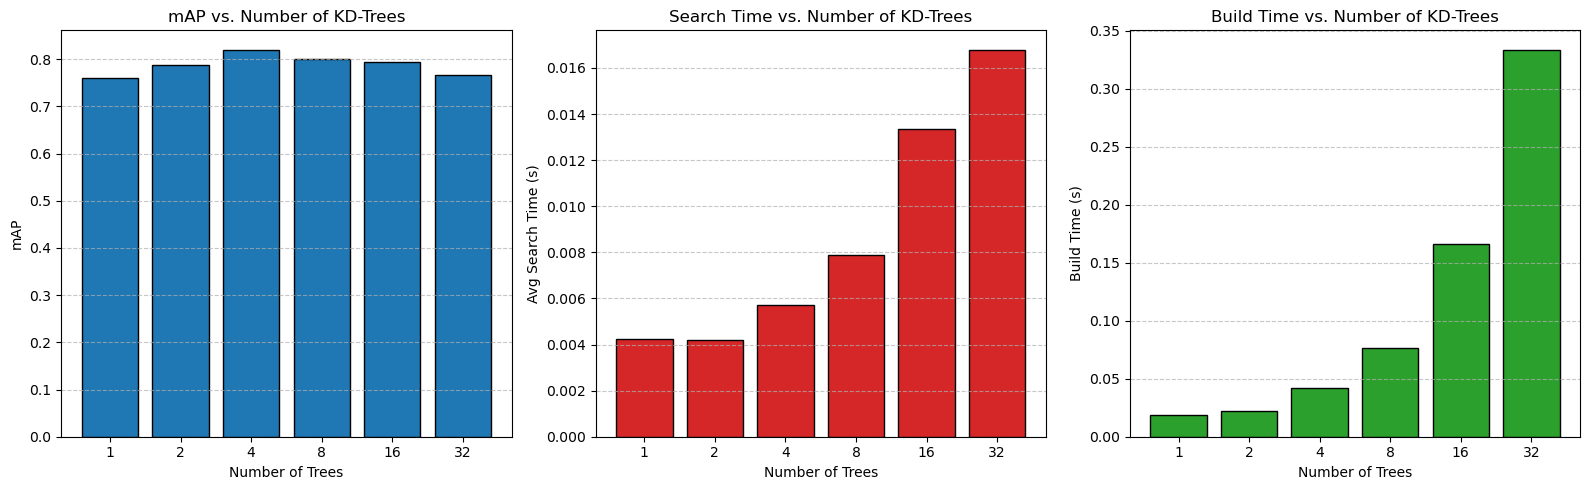

In [ ]:
tree_counts = [1, 2, 4, 8, 16, 32]

mAP_scores = []
build_times = []
avg_search_times = []

max_desc = 400
queries = dataset.get_query_images()

print("Evaluating KD-Tree performance across different tree counts...")
print("-" * 65)
print(f"{'Trees':<10} | {'mAP':<10} | {'Build Time (s)':<15} | {'Avg Search Time/Query (s)'}")
print("-" * 65)

for num_trees in tree_counts:
    start_build = time.time()
    flann, image_map = a2.build_kdtree(dataset, max_descriptors=max_desc, num_trees=num_trees)
    build_time = time.time() - start_build
    ranked_dict = {}
    
    start_search = time.time()
    for query_image in queries:
        query_descs = dataset.get_descriptors(query_image)
        if query_descs is None:
            continue
        query_descs = query_descs[:max_desc]
        ranked_indices = a2.search_kdtree(query_descs, flann)
        ranked_dict[query_image] = [image_map[idx] for idx in ranked_indices]
        
    total_search_time = time.time() - start_search
    avg_search_time = total_search_time / len(queries)
    current_map = dataset.compute_mAP(ranked_dict)
    mAP_scores.append(current_map)
    build_times.append(build_time)
    avg_search_times.append(avg_search_time)
    
    print(f"{num_trees:<10} | {current_map:<10.5f} | {build_time:<15.5f} | {avg_search_time:.5f}")

# --- Plotting the Results ---

x_labels = [str(t) for t in tree_counts]
x_pos = np.arange(len(x_labels))

# Create a figure with 3 side-by-side subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot mAP
ax1.bar(x_pos, mAP_scores, color='tab:blue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.set_xlabel('Number of Trees')
ax1.set_ylabel('mAP')
ax1.set_title('mAP vs. Number of KD-Trees')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Plot Average Search Time
ax2.bar(x_pos, avg_search_times, color='tab:red', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_xlabel('Number of Trees')
ax2.set_ylabel('Avg Search Time (s)')
ax2.set_title('Search Time vs. Number of KD-Trees')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Plot Build Time
ax3.bar(x_pos, build_times, color='tab:green', edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels)
ax3.set_xlabel('Number of Trees')
ax3.set_ylabel('Build Time (s)')
ax3.set_title('Build Time vs. Number of KD-Trees')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.show()

**Task 4:**

Analyze the effect of changing the number of descriptors per image on both mAP and average response time. Keep in mind that using too many descriptors may consume **significant memory** on your computer. Visualizing the results with plots could help justify your analysis.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

Evaluating KD-Tree performance across different descriptor counts...
-----------------------------------------------------------------
Max Descriptors | mAP        | Build Time (s)  | Avg Search Time (s)
-----------------------------------------------------------------
50              | 0.41228    | 0.00877         | 0.00057
100             | 0.53509    | 0.00943         | 0.00106
200             | 0.74561    | 0.02005         | 0.00236
400             | 0.76754    | 0.04059         | 0.00598
800             | 0.83772    | 0.10921         | 0.01449
1600            | 0.90789    | 0.20437         | 0.03242


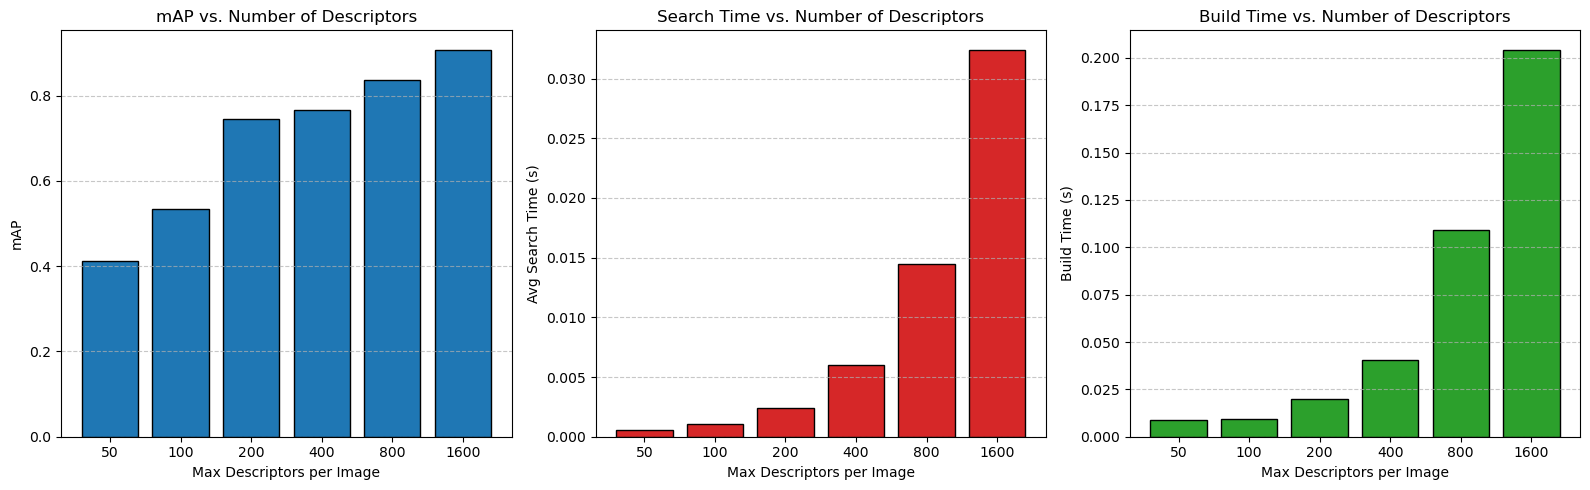

In [ ]:
descriptor_counts = [50, 100, 200, 400, 800, 1600]
num_trees = 4

map_scores_desc = []
avg_search_times_desc = []
build_times_desc = []

queries = dataset.get_query_images()

print("Evaluating KD-Tree performance across different descriptor counts...")
print("-" * 65)
print(f"{'Max Descriptors':<15} | {'mAP':<10} | {'Build Time (s)':<15} | {'Avg Search Time (s)'}")
print("-" * 65)

for max_desc in descriptor_counts:
    start_build = time.time()
    flann, image_map = a2.build_kdtree(dataset, max_descriptors=max_desc, num_trees=num_trees)
    build_time = time.time() - start_build
    ranked_dict = {}

    start_search = time.time()
    for query_image in queries:
        query_descs = dataset.get_descriptors(query_image)
        if query_descs is None:
            continue
        query_descs = query_descs[:max_desc]
        ranked_indices = a2.search_kdtree(query_descs, flann)
        ranked_dict[query_image] = [image_map[idx] for idx in ranked_indices]
        
    total_search_time = time.time() - start_search
    avg_search_time = total_search_time / len(queries)
    current_map = dataset.compute_mAP(ranked_dict)
    map_scores_desc.append(current_map)
    build_times_desc.append(build_time)
    avg_search_times_desc.append(avg_search_time)
    
    print(f"{max_desc:<15} | {current_map:<10.5f} | {build_time:<15.5f} | {avg_search_time:.5f}")


# --- Plotting the Results ---
x_labels = [str(d) for d in descriptor_counts]
x_pos = np.arange(len(x_labels))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot mAP
ax1.bar(x_pos, map_scores_desc, color='tab:blue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.set_xlabel('Max Descriptors per Image')
ax1.set_ylabel('mAP')
ax1.set_title('mAP vs. Number of Descriptors')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Plot Average Search Time
ax2.bar(x_pos, avg_search_times_desc, color='tab:red', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_xlabel('Max Descriptors per Image')
ax2.set_ylabel('Avg Search Time (s)')
ax2.set_title('Search Time vs. Number of Descriptors')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Plot Build Time
ax3.bar(x_pos, build_times_desc, color='tab:green', edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels)
ax3.set_xlabel('Max Descriptors per Image')
ax3.set_ylabel('Build Time (s)')
ax3.set_title('Build Time vs. Number of Descriptors')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

fig.tight_layout()
plt.show()

# **Locality-Sensitive Hashing (LSH)**

In this section, we will explore how to use **Locality-Sensitive Hashing (LSH)** to efficiently index and search an image database. We will utilize **[FAISS](https://github.com/facebookresearch/faiss) (Facebook AI Similarity Search)**, an optimized library for large-scale similarity search, which is widely used for tasks such as image retrieval, nearest neighbor search, and clustering.

LSH is a technique that maps high-dimensional vectors into a lower-dimensional space using **random projections**. The key idea behind LSH is to ensure that similar vectors (in terms of Euclidean or Cosine distance) are **hashed into the same or nearby buckets**, allowing for faster retrieval. FAISS implements LSH by **projecting each descriptor onto a set of random hyperplanes**. The sign of each projection (positive or negative) determines a **binary code** for that descriptor, effectively mapping it into a lower-dimensional Hamming space.

One of the most important parameters in LSH indexing in FAISS is **`nbits`**, which defines the **final number of bits** each descriptor is converted into and, hence, the **number of hyperplanes** used for hashing.

- Start by implementing the function `build_lsh` in the `assignment2.py` file, which will create an LSH index using FAISS and store the image descriptors efficiently for fast retrieval.

> **Useful links**: [FAISS Tutorial](https://github.com/facebookresearch/faiss/wiki/getting-started), [Random Projection for Locality Sensitive Hashing](https://www.pinecone.io/learn/series/faiss/locality-sensitive-hashing-random-projection/)

- Next, implement the function `search_lsh` in the `assignment2.py` file. Unlike previous implementations, this function searches the LSH index for the best matching images for multiple query images simultaneously, as FAISS is more efficient when processing batch queries instead of one at a time.

**Task 5:**

Using the `HolidaysDatasetHandler` and the functions you have implemented, your task in the following cell is to compute the **mean Average Precision (mAP)** of the image retrieval system for this dataset, utilizing an FAISS-based LSH index. For this exercise, we will extract **400 descriptors per image** for efficiency and start with an initial configuration of **`nbits = 128`**, meaning each descriptor will be mapped into a **128-bit hash**.

In [30]:
# Fill this variable with the resulting mAP
mAP_lsh = 0.0

# YOUR CODE HERE

def calculate_mAP_lsh(dataset, max_descriptors=400, num_bits=128):

    query_descs_dict = {}

    query_images = dataset.get_query_images()
    for filename in query_images:
       
        curr_descriptors = dataset.get_descriptors(filename)
        if curr_descriptors is None:
            continue
        query_descs_dict[filename] = curr_descriptors

    lsh_index, image_map = a2.build_lsh(dataset, max_descriptors=max_descriptors, num_bits=num_bits)
    ranked_dict = a2.search_lsh(query_descs_dict, lsh_index, image_map, k=2)

    mAP_lsh = dataset.compute_mAP(ranked_dict)

    return mAP_lsh 

mAP_lsh = calculate_mAP_lsh(dataset, max_descriptors=400, num_bits=128)
# -----

print('Mean Average Precision (mAP) using LSH:', round(mAP_lsh, 5))

Mean Average Precision (mAP) using LSH: 0.61619


**Task 6:**

Analyze the impact of changing the number of bits (i.e., the number of projections and hash size) on both **mAP (Mean Average Precision)** and **average response** time. Since using an excessively high number of bits can significantly increase memory consumption, discretize a few key values and study their effects. To support your analysis, consider visualizing the results with plots, as this can help illustrate trends and justify your conclusions.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

In [32]:
num_bits_arr = [4,8,16,32,64,128,256,512]

for num_bits in num_bits_arr:
    start = time.time()
    curr_mAP_lsh = calculate_mAP_lsh(dataset, max_descriptors=400, num_bits=num_bits)
    end = time.time()
    time_elapsed = end - start  

    print(f"mAP: {curr_mAP_lsh:5f} - Num Bits: {num_bits} - Time Elapsed: {time_elapsed}")

mAP: 0.055921 - Num Bits: 4 - Time Elapsed: 0.8202059268951416
mAP: 0.157003 - Num Bits: 8 - Time Elapsed: 0.7641661167144775
mAP: 0.183764 - Num Bits: 16 - Time Elapsed: 0.8143837451934814
mAP: 0.285759 - Num Bits: 32 - Time Elapsed: 0.5492689609527588
mAP: 0.452875 - Num Bits: 64 - Time Elapsed: 0.5533549785614014
mAP: 0.616186 - Num Bits: 128 - Time Elapsed: 0.5734589099884033
mAP: 0.720339 - Num Bits: 256 - Time Elapsed: 0.5904052257537842
mAP: 0.819152 - Num Bits: 512 - Time Elapsed: 0.813316822052002


**Task 7:**

Compare the performance of **randomized k-d trees** and **LSH** from multiple perspectives, including accuracy, training time, and querying time. Since each approach has different trade-offs, analyzing their efficiency across these aspects will provide valuable insights. Visualizing the results with plots can be particularly useful to support and justify your conclusions.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

# **Bag-of-Words (BoW)**

In this exercise, you will implement an image retrieval system based on the **Bag-of-Words (BoW) model** using SIFT descriptors extracted from images. The system will include:

- A **visual vocabulary** loaded from a precomputed `.fvecs` file.
- A **FAISS L2 index** to efficiently quantize descriptors and assign them to visual words.
- An **inverted file index** to enable fast lookup of relevant images.
- **TF-IDF weighting** to enhance retrieval accuracy by prioritizing discriminative visual words.

### Visual Vocabularies

To implement a **Bag-of-Words (BoW) model**, we first need a **visual vocabulary**. The authors of the **INRIA Holidays dataset** provide precomputed visual vocabularies, trained using a clustering method (e.g., **$k$-means**) on a separate dataset (**Flickr60K**). These vocabularies are included in the dataset directory under the **`vocabs/`** subfolder. Each file corresponds to a vocabulary of different sizes, containing 100, 200, 500, 1K, 2K, 5K, 10K, 20K, 50K, 100K, and 200K visual words. Since these vocabularies are stored in binary format, we will provide functions to correctly load them into your program.

###  Implementing the Model

Start by implementing the missing methods in the `BagOfWordsRetriever` class in `assignment2.py` as indicated.

**Task 8:**

Using the `HolidaysDatasetHandler` and `BagOfWordsRetriever` classes, your task in the following cell is to compute the **mean Average Precision (mAP)** of the image retrieval system for this dataset **using the vocabularies of 200, 2K, 10K and 20K visual words**. Depending on your machine, this may take some time, as we are performing a linear search over the dictionary. Please allow some time for this part of the notebook to execute. You may try a different FAISS index, but please note that it could affect the mAP.

In [14]:
# Fill these variables with the resulting mAP
mAP_200  = 0.0
mAP_2K   = 0.0
mAP_10K  = 0.0
mAP_20K  = 0.0

# YOUR CODE HERE

def calculate_mAP_bow(vocab_file):
    t0 = time.perf_counter()
    bow = a2.BagOfWordsRetriever(dataset, vocab_file)


    for img in dataset.get_database_images():
        curr_descriptors = dataset.get_descriptors(img)
        if curr_descriptors is None:
            continue
        bow.compute_bow_representation(img, curr_descriptors)

    bow.apply_tfidf() 

    train_time = time.perf_counter() - t0

    ranked_dict = {}
    query_images = dataset.get_query_images()
    t0 = time.perf_counter()

    for query in query_images:
        results = bow.retrieve_images(query)
        ranked_dict[query] = [name for name, score in results]

    query_time_total = time.perf_counter() - t0

    avg_query_time = query_time_total / len(query_images)
    mAP = dataset.compute_mAP(ranked_dict)

    return mAP, train_time, avg_query_time

# -----

vocab_files = {
    "200": "holidays_mini/vocabs/vocab_k200.fvecs",
    "2k":  "holidays_mini/vocabs/vocab_k2000.fvecs",
    "10k": "holidays_mini/vocabs/vocab_k10000.fvecs",
    "20k": "holidays_mini/vocabs/vocab_k20000.fvecs",
}

results = {}
for label, path in vocab_files.items():
    mAP, train_time, avg_query_time = calculate_mAP_bow(path)
    results[label] = {
        "mAP": mAP,
        "train_time": train_time,
        "avg_query_time": avg_query_time,
    }
    print(f"Vocab {label:>4}: mAP={mAP:.5f}  "
          f"train={train_time:.4f}s  query/img={avg_query_time*1000:.3f}ms")

mAP_200 = results["200"]["mAP"]
mAP_2k  = results["2k"]["mAP"]
mAP_10k = results["10k"]["mAP"]
mAP_20k = results["20k"]["mAP"]

Vocab  200: mAP=0.73807  train=0.2693s  query/img=5.698ms
Vocab   2k: mAP=0.72588  train=0.9002s  query/img=30.616ms
Vocab  10k: mAP=0.69653  train=3.0735s  query/img=137.559ms
Vocab  20k: mAP=0.72661  train=6.6244s  query/img=265.704ms


**Task 9:**

Compare the performance results obtained for each case. Is a larger vocabulary size always advantageous? Justify your answer.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

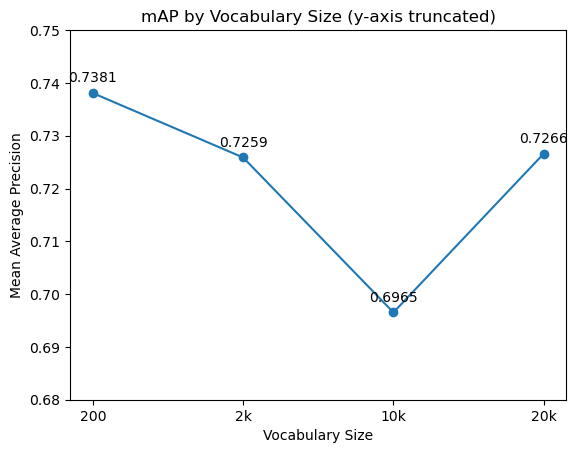

In [16]:
labels = list(results.keys())
maps = [results[label]["mAP"] for label in labels]

fig, ax = plt.subplots()

ax.plot(labels, maps, marker='o', linestyle='-')

for x, y in zip(labels, maps):
    ax.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

ax.set_ylim(0.68, 0.75)  

ax.set_ylabel('Mean Average Precision')
ax.set_xlabel('Vocabulary Size')
ax.set_title('mAP by Vocabulary Size (y-axis truncated)')

plt.show()

**Task 10:**

Analyze the impact of vocabulary size on mAP and average response time (including both training and query times). Are these times consistent across different vocabulary sizes? Including plots here could help support your answer.

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

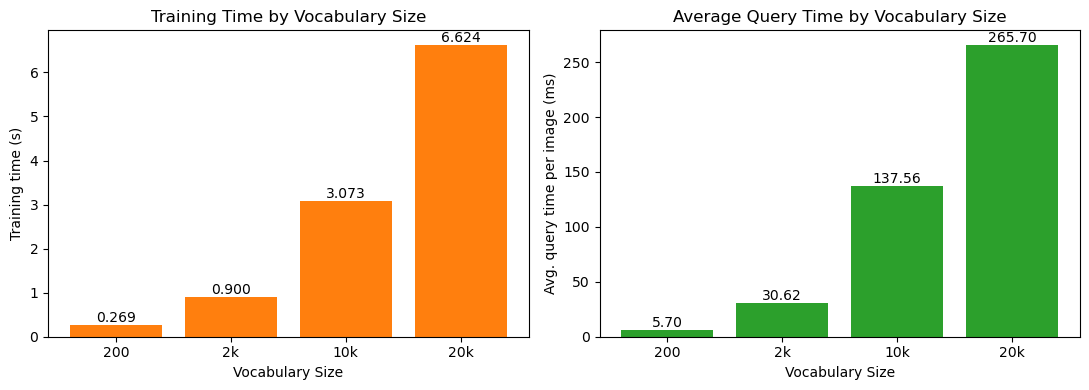

In [ ]:
labels = list(results.keys())
train_times    = [results[l]["train_time"] for l in labels]
query_times_ms = [results[l]["avg_query_time"] * 1000 for l in labels]   # s → ms

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars1 = axes[0].bar(labels, train_times, color='tab:orange')
axes[0].bar_label(bars1, fmt='%.3f')
axes[0].set_ylabel('Training time (s)')
axes[0].set_xlabel('Vocabulary Size')
axes[0].set_title('Training Time by Vocabulary Size')

bars2 = axes[1].bar(labels, query_times_ms, color='tab:green')
axes[1].bar_label(bars2, fmt='%.2f')
axes[1].set_ylabel('Avg. query time per image (ms)')
axes[1].set_xlabel('Vocabulary Size')
axes[1].set_title('Average Query Time by Vocabulary Size')

fig.tight_layout()
plt.show()

**Task 11:**

Do the results depend on the set of images used to generate the vocabulary? How can retrieval performance be improved?

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

**Task 12:**

How does TF-IDF impact performance? Does it improve or degrade results? Does this outcome make sense?

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

# **Deep Learning Retrieval with HNSW**

In this exercise, you will implement a modern image retrieval system based on **Deep Features** extracted using a Convolutional Neural Network (CNN) and indexed with a Hierarchical Navigable Small World (**HNSW**) graph. The system will include:

- Deep Feature Extraction: Using a pre-trained **ResNet-50** model to obtain high-dimensional semantic vectors (embeddings) for each image.

- HNSW Indexing: A graph-based index implemented with **FAISS** to enable fast approximate nearest neighbor (ANN) search in high-dimensional spaces.

### Deep Features
Unlike local descriptors (e.g., SIFT) which require quantization into a visual vocabulary, Deep Learning models map entire images directly into a compact vector space where semantic similarity is preserved. We will use again the ResNet-50 architecture, pre-trained on ImageNet, to extract a 2048-dimensional embedding for every image in the dataset. Since extracting these features can be computationally expensive in this assignment, this time you are provided with a precomputed file (`holidays_deep_features.npy`) containing the feature vectors for the entire dataset.

To load these features, use the following code:
```python
deep_features = np.load('holidays_deep_features.npy', allow_pickle=True).item()
```

The raw vectors from the CNN are not normalized. Since we want to use Cosine Similarity as our similarity measure, you must apply L2 normalization to both the database vectors and the query vectors before indexing or searching.

- To achieve this, start by implementing the function `build_hnsw` in the `assignment2.py` file. This function will take the dataset handler and the dictionary of deep features as input. It must extract the database vectors, perform L2 normalization, and construct an HNSW index using FAISS (faiss.IndexHNSWFlat). You must configure the index with the number of connections $M=32$ and use the faiss.METRIC_INNER_PRODUCT to simulate Cosine Similarity. The function should return the built index and the image map (the list of image names corresponding to the indexed vectors).

> **Useful links**: [FAISS HNSW Index](https://github.com/facebookresearch/faiss/wiki/The-index-factory)

- Next, implement the function `search_hnsw` in the `assignment2.py` file. This function performs an approximate nearest neighbor search using the HNSW index (previously trained with `build_hnsw`) on the provided query descriptors (passed as the first argument). It returns the distances and indices of the $k$ nearest neighbors. Ensure you apply the same L2 normalization to the query vectors before searching.

**Task 13:**

Using the `HolidaysDatasetHandler` and the functions you have implemented, your task in the following cell is to compute the **mean Average Precision (mAP)** of the image retrieval system for this dataset using the HNSW index and the Deep descriptors.

In [ ]:
# Fill these variables with the resulting mAP
mAP_hnsw  = 0.0

# YOUR CODE HERE
deep_features = np.load(Path(dataset_dir) / 'holidays_deep_features.npy', allow_pickle=True).item()
print("Building HNSW Index...")
hnsw_index, image_map = a2.build_hnsw(dataset, deep_features, M=32)
query_descs_dict = {}
for q_img in dataset.get_query_images():
    if q_img in deep_features:
        query_descs_dict[q_img] = deep_features[q_img]
print("Searching...")
ranked_dict = a2.search_hnsw(query_descs_dict, hnsw_index, image_map, k=500) 
mAP_hnsw = dataset.compute_mAP(ranked_dict)
# -----

print('Mean Average Precision (mAP) using HNSW: %.5f' % mAP_hnsw)

Building HNSW Index...
Searching...
Mean Average Precision (mAP) using HNSW: 0.98684


**Task 14:**

Analyze the effect of HNSW parameters on performance. Evaluate the approach in terms of speed and computational cost. How does it compare to previous solutions?

*Write in the following the code required to answer the question. You may add more code or markdown cells as needed.*

Evaluating HNSW performance across different parameter profiles...
--------------------------------------------------------------------------------
Profile                   | mAP        | Build Time (s)  | Avg Search Time (s)
--------------------------------------------------------------------------------
Fast                      | 0.98684    | 0.00148         | 0.00002
Balanced                  | 0.98684    | 0.00036         | 0.00002
Accurate                  | 0.98684    | 0.00034         | 0.00005


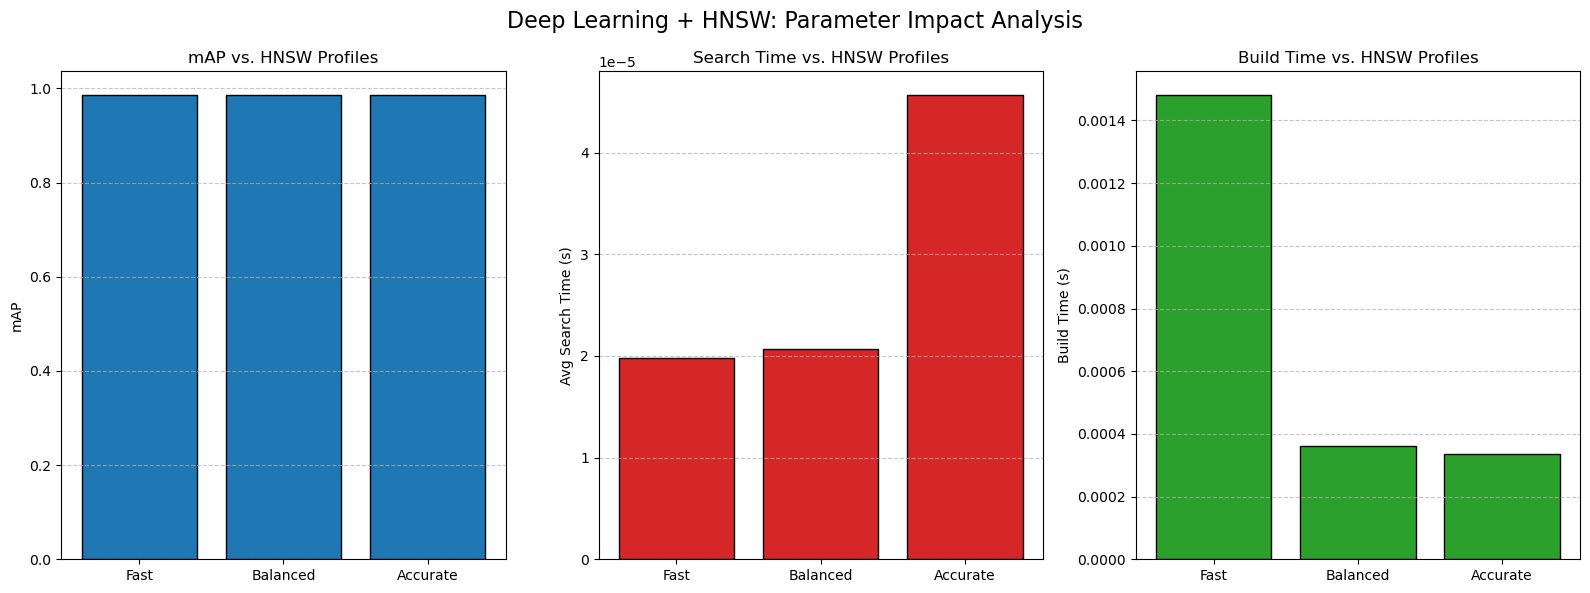

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt

configs = [
    {'name': 'Fast', 'M': 16, 'efConst': 32, 'efSearch': 16, 'k': 20},
    {'name': 'Balanced', 'M': 32, 'efConst': 64, 'efSearch': 64, 'k': 100},
    {'name': 'Accurate', 'M': 64, 'efConst': 128, 'efSearch': 128, 'k': 500}
]

map_scores_hnsw = []
build_times_hnsw = []
avg_search_times_hnsw = []

queries = dataset.get_query_images()
query_descs_dict = {q: deep_features[q] for q in queries if q in deep_features}

print("Evaluating HNSW performance across different parameter profiles...")
print("-" * 80)
print(f"{'Profile':<25} | {'mAP':<10} | {'Build Time (s)':<15} | {'Avg Search Time (s)'}")
print("-" * 80)

for conf in configs:
    # 1. Measure Build Time
    start_build = time.time()
    # Note: We pass efConstruction inside build_hnsw based on the function we wrote earlier
    hnsw_index, image_map = a2.build_hnsw(dataset, deep_features, M=conf['M'], efConstruction=conf['efConst'])
    build_time = time.time() - start_build
    
    # 2. Measure Search Time
    start_search = time.time()
    ranked_dict = a2.search_hnsw(
        query_descs_dict, 
        hnsw_index, 
        image_map, 
        k=conf['k'], 
        efSearch=conf['efSearch']
    )
    total_search_time = time.time() - start_search
    avg_search_time = total_search_time / len(queries)
    
    # 3. Compute mAP
    current_map = dataset.compute_mAP(ranked_dict)
    
    # Store metrics for plotting
    map_scores_hnsw.append(current_map)
    build_times_hnsw.append(build_time)
    avg_search_times_hnsw.append(avg_search_time)
    
    # Using replace to keep terminal output clean
    clean_name = conf['name'].replace('\n', ' ')
    print(f"{clean_name:<25} | {current_map:<10.5f} | {build_time:<15.5f} | {avg_search_time:.5f}")


# --- Plotting the Results (Bar Plots) ---
x_labels = [c['name'] for c in configs]
x_pos = np.arange(len(x_labels))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

# 1. Plot mAP
ax1.bar(x_pos, map_scores_hnsw, color='tab:blue', edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.set_ylabel('mAP')
ax1.set_title('mAP vs. HNSW Profiles')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Plot Average Search Time
ax2.bar(x_pos, avg_search_times_hnsw, color='tab:red', edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels)
ax2.set_ylabel('Avg Search Time (s)')
ax2.set_title('Search Time vs. HNSW Profiles')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Plot Build Time
ax3.bar(x_pos, build_times_hnsw, color='tab:green', edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels)
ax3.set_ylabel('Build Time (s)')
ax3.set_title('Build Time vs. HNSW Profiles')
ax3.grid(axis='y', linestyle='--', alpha=0.7)

fig.suptitle('Deep Learning + HNSW: Parameter Impact Analysis', fontsize=16)
fig.tight_layout()
plt.show()

## Submitting Your Work

**Important**: Please ensure that the notebook has been run and that the **cell outputs are visible**.

**Important**: Additionally, make sure you have filled in the names at the beginning of the notebook and the **ID** variable in the following cell.

Once you have completed the necessary code and are satisfied with your solution, **save your notebook** and run the following cell:

In [ ]:
ID = '99999999R' # Your DNI or NIE

zip_filename = ID + '_A2.zip'
zf = zipfile.ZipFile(zip_filename, mode = 'w')

zf.write('11762_Image_Indexing.ipynb');
zf.write('assignment2.py');
zf.write('holidays_dataset_handler.py');
zf.write('holidays_deep_features.npy');

zf.close()

This will generate a zip file of your code called `ID_A2.zip` in the same directory of the assignment. This is the file that you must upload to [Aula Digital](https://ad.uib.es/) to submit your work!

---

&copy; Emilio Garcia-Fidalgo, University of the Balearic Islands